TensorFlow 2.19.0
GPU: False
Train: (210, 2)  Val: (90, 2)


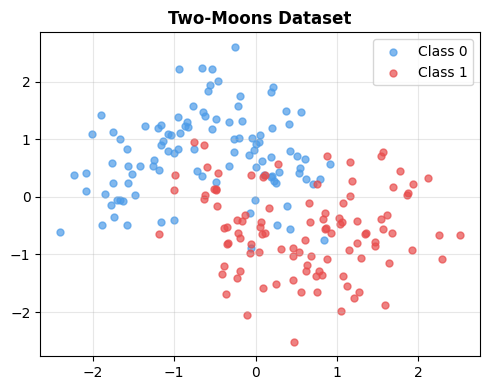

In [10]:
# ============================================================
# Dropout Regularization — A/B Test (TensorFlow/Keras)
# Variants: No Dropout | Standard | SpatialDropout | AlphaDropout
# ============================================================

# ─────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
tf.random.set_seed(42)
print(f"TensorFlow {tf.__version__}")
print("GPU:", len(tf.config.list_physical_devices('GPU')) > 0)

# ─────────────────────────────────────────────
# CELL 2 — Dataset
# Small + noisy → easy to overfit without dropout
# ─────────────────────────────────────────────
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}  Val: {X_val.shape}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(*X_train[y_train==0].T, c='#4C9BE8', s=25, alpha=0.7, label='Class 0')
ax.scatter(*X_train[y_train==1].T, c='#E84C4C', s=25, alpha=0.7, label='Class 1')
ax.set_title('Two-Moons Dataset', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [11]:
# ─────────────────────────────────────────────
# CELL 3 — Model factory
#
# KEY CONCEPT — Keras dropout types:
#
# layers.Dropout(rate)
#   → randomly zeros individual activations with prob=rate
#   → works on any layer type
#   → most common; good for Dense layers
#
# layers.SpatialDropout2D(rate)
#   → drops entire feature MAPS (channels) instead of individual units
#   → designed for CNNs — adjacent pixels are correlated, so
#     dropping individual pixels doesn't help much
#
# layers.AlphaDropout(rate)
#   → designed specifically for SELU activations
#   → preserves the self-normalizing property of SELU
#     (mean ≈ 0, variance ≈ 1) after dropout
#   → standard Dropout + SELU breaks normalization; AlphaDropout fixes this
# ─────────────────────────────────────────────
DROPOUT_RATE = 0.4   # ← try 0.1, 0.3, 0.5, 0.7 to see effect

def build_model(dropout_type='none', rate=DROPOUT_RATE, name='model'):
    """
    dropout_type: 'none' | 'standard' | 'alpha'
    (SpatialDropout2D shown separately on CNN — needs 4D input)
    """
    inp = keras.Input(shape=(2,))

    if dropout_type == 'none':
        # No dropout — large network will memorise training data
        x = layers.Dense(256, activation='relu')(inp)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dense(256, activation='relu')(x)

    elif dropout_type == 'standard':
        # Standard Dropout: randomly zero activations during training
        # At inference: training=False disables dropout automatically
        x = layers.Dense(256, activation='relu')(inp)
        x = layers.Dropout(rate)(x)          # ← added after each dense
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(rate)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(rate)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(rate)(x)

    elif dropout_type == 'alpha':
        # AlphaDropout: use with SELU activation
        # SELU is self-normalising — AlphaDropout preserves this property
        x = layers.Dense(256, activation='selu',
                         kernel_initializer='lecun_normal')(inp)
        x = layers.AlphaDropout(rate)(x)     # ← AlphaDropout + SELU pair
        x = layers.Dense(256, activation='selu',
                         kernel_initializer='lecun_normal')(x)
        x = layers.AlphaDropout(rate)(x)
        x = layers.Dense(256, activation='selu',
                         kernel_initializer='lecun_normal')(x)
        x = layers.AlphaDropout(rate)(x)
        x = layers.Dense(256, activation='selu',
                         kernel_initializer='lecun_normal')(x)
        x = layers.AlphaDropout(rate)(x)

    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Print summary for one variant
build_model('standard').summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_120 (Dense)               │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_121 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_122 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_123 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_124 (Dense)               │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,401 (775.00 KB)

 Trainable params: 198,401 (775.00 KB)

 Non-trainable params: 0 (0.00 B)


── Training: No Dropout ──
  Best val acc: 0.9111

── Training: Standard Dropout ──
  Best val acc: 0.8889

── Training: AlphaDropout+SELU ──
  Best val acc: 0.8444


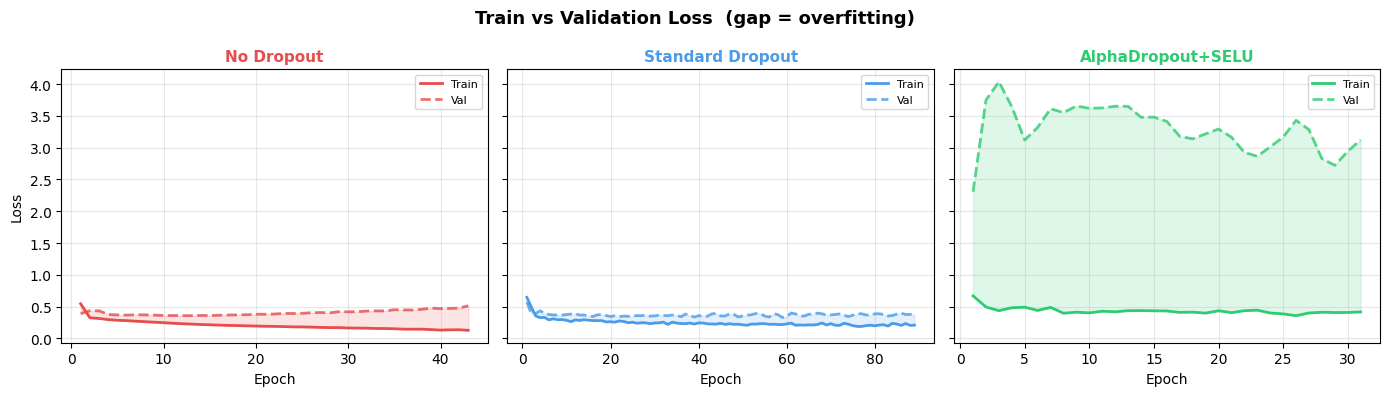


💡 No Dropout: large gap between train/val → overfitting
   With Dropout: gap shrinks → model generalises better


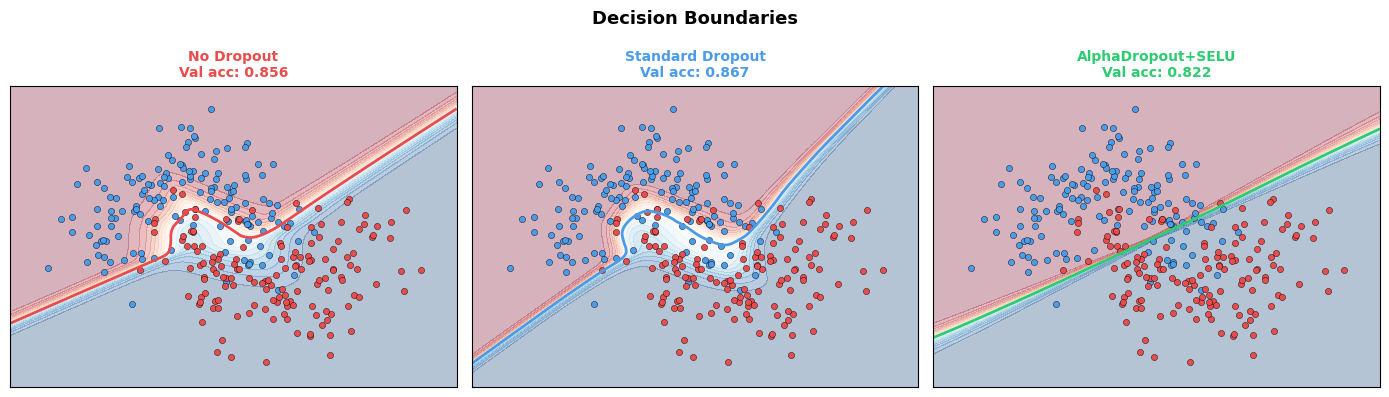

In [12]:
# ─────────────────────────────────────────────
# CELL 4 — A/B Training loop
# ─────────────────────────────────────────────
EPOCHS  = 400
BS      = 32

VARIANTS = [
    ('none',     'No Dropout',       '#E84C4C'),
    ('standard', 'Standard Dropout', '#4C9BE8'),
    ('alpha',    'AlphaDropout+SELU','#2ECC71'),
]

histories, models = {}, {}

for dtype, label, color in VARIANTS:
    print(f'\n── Training: {label} ──')
    m = build_model(dropout_type=dtype, rate=DROPOUT_RATE, name=dtype)
    h = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS, batch_size=BS, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=30, restore_best_weights=True
        )]
    )
    histories[dtype] = h.history
    models[dtype]    = m
    print(f"  Best val acc: {max(h.history['val_accuracy']):.4f}")

# ─────────────────────────────────────────────
# CELL 5 — Plot A: Loss curves
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle('Train vs Validation Loss  (gap = overfitting)',
             fontsize=13, fontweight='bold')

for ax, (dtype, label, color) in zip(axes, VARIANTS):
    h  = histories[dtype]
    ep = range(1, len(h['loss'])+1)
    ax.plot(ep, h['loss'],     color=color, lw=2,       label='Train')
    ax.plot(ep, h['val_loss'], color=color, lw=2, ls='--', label='Val', alpha=0.8)
    ax.fill_between(ep, h['loss'], h['val_loss'], alpha=0.15, color=color)
    ax.set_title(label, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

axes[0].set_ylabel('Loss')
plt.tight_layout(); plt.show()

print('\n💡 No Dropout: large gap between train/val → overfitting')
print('   With Dropout: gap shrinks → model generalises better')

# ─────────────────────────────────────────────
# CELL 6 — Plot B: Decision boundaries
# ─────────────────────────────────────────────
def plot_boundary(ax, model, X, y, title, color):
    h = 0.03
    x0, x1 = X[:,0].min()-.5, X[:,0].max()+.5
    y0, y1 = X[:,1].min()-.5, X[:,1].max()+.5
    xx, yy = np.meshgrid(np.arange(x0,x1,h), np.arange(y0,y1,h))
    Z = model.predict(np.c_[xx.ravel(),yy.ravel()], verbose=0).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu', levels=20)
    ax.contour( xx, yy, Z, levels=[0.5], colors=[color], linewidths=2)
    ax.scatter(*X[y==0].T, c='#4C9BE8', s=20, edgecolors='k', lw=0.3)
    ax.scatter(*X[y==1].T, c='#E84C4C', s=20, edgecolors='k', lw=0.3)
    va = ((model.predict(X_val, verbose=0).ravel()>0.5).astype(int)==y_val).mean()
    ax.set_title(f'{title}\nVal acc: {va:.3f}',
                 fontsize=10, fontweight='bold', color=color)
    ax.set_xticks([]); ax.set_yticks([])

X_all = np.vstack([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Decision Boundaries', fontsize=13, fontweight='bold')
for ax, (dtype, label, color) in zip(axes, VARIANTS):
    plot_boundary(ax, models[dtype], X_all, y_all, label, color)
plt.tight_layout(); plt.show()

rate=0.0  train=0.929  val=0.889
rate=0.1  train=0.914  val=0.878
rate=0.2  train=0.924  val=0.878
rate=0.3  train=0.910  val=0.878
rate=0.4  train=0.914  val=0.878
rate=0.5  train=0.914  val=0.878
rate=0.6  train=0.914  val=0.867
rate=0.7  train=0.886  val=0.856


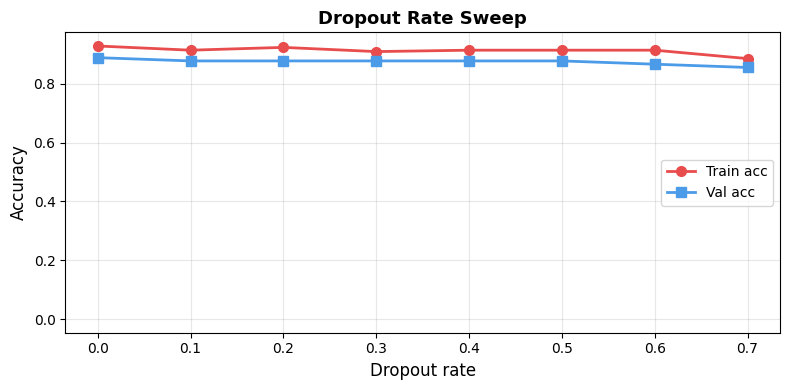


💡 rate=0.0  → no regularisation → train >> val (overfit)
   rate=0.4  → sweet spot for this dataset
   rate=0.7  → too aggressive → underfitting (both low)


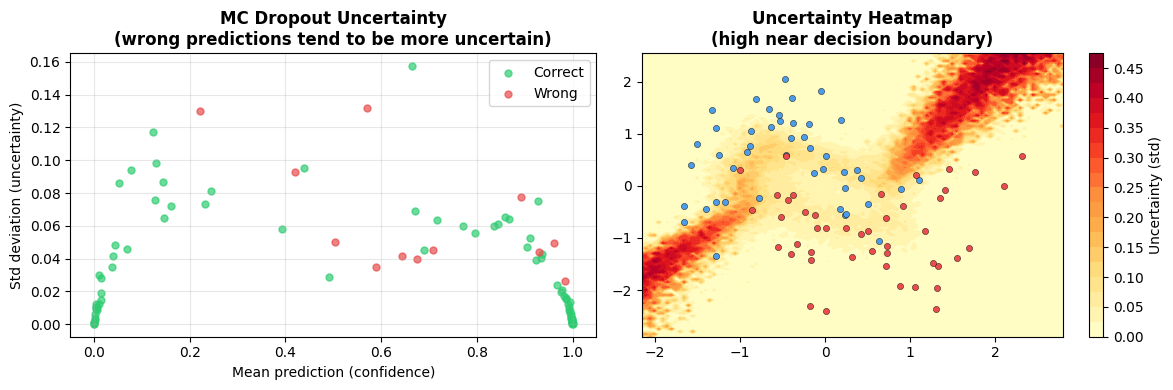


💡 MC Dropout gives FREE uncertainty estimates from a trained model
   High uncertainty → near decision boundary → model is unsure
   Use uncertainty to flag predictions for human review in production
Variant                   Train      Val      Gap
No Dropout               0.9381   0.9111   0.0270 ✅
Standard Dropout         0.9238   0.8889   0.0349 ✅
AlphaDropout+SELU        0.8619   0.8444   0.0175 ✅

HOW DROPOUT WORKS — RECAP
──────────────────────────────────────────────────────
Training:  each neuron zeroed with prob=rate
           scale surviving activations by 1/(1-rate)
           → inverted dropout (no scaling needed at test time)

Inference: training=False → dropout DISABLED automatically
           all neurons active, outputs at correct magnitude

Why it works:
  • Forces redundant representations (no single neuron relied on)
  • Equivalent to training an ensemble of 2^n sub-networks
  • Acts as implicit L2 regularisation on weights

Standard Dropout:  drop individual acti

In [14]:
# ─────────────────────────────────────────────
# CELL 7 — Plot C: Dropout rate sweep
# How does rate affect train accuracy, val accuracy, and the gap?
# ─────────────────────────────────────────────
rates       = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
sweep_train = []
sweep_val   = []

for r in rates:
    dtype = 'none' if r == 0.0 else 'standard'
    m = build_model(dropout_type=dtype, rate=r)
    h = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=300, batch_size=32, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(
            patience=20, restore_best_weights=True)])
    sweep_train.append(max(h.history['accuracy']))
    sweep_val.append(max(h.history['val_accuracy']))
    print(f"rate={r:.1f}  train={sweep_train[-1]:.3f}  val={sweep_val[-1]:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rates, sweep_train, 'o-', color='#E84C4C', lw=2, ms=7, label='Train acc')
ax.plot(rates, sweep_val,   's-', color='#4C9BE8', lw=2, ms=7, label='Val acc')
ax.fill_between(rates,
                [t-v for t,v in zip(sweep_train, sweep_val)],
                alpha=0.0)
ax.set_xlabel('Dropout rate', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Dropout Rate Sweep', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('\n💡 rate=0.0  → no regularisation → train >> val (overfit)')
print('   rate=0.4  → sweet spot for this dataset')
print('   rate=0.7  → too aggressive → underfitting (both low)')

# ─────────────────────────────────────────────
# CELL 8 — MC Dropout: dropout at INFERENCE time for uncertainty
#
# KEY CONCEPT:
#   Normally dropout is OFF during inference (training=False).
#   MC Dropout keeps it ON: run N forward passes with different
#   masks → get N different predictions → mean = prediction,
#   std = uncertainty estimate.
#   This approximates Bayesian inference cheaply.
# ─────────────────────────────────────────────
N_PASSES = 50   # number of stochastic forward passes

model_mc = models['standard']   # reuse our trained dropout model

# Force training=True at inference to keep dropout active
@tf.function
def mc_predict(x, training=True):
    return model_mc(x, training=training)

# Run N passes on validation set
preds = np.stack([
    mc_predict(tf.constant(X_val, dtype=tf.float32)).numpy()
    for _ in range(N_PASSES)
])  # shape: (N_PASSES, n_val)

mean_pred = preds.mean(axis=0).flatten()   # point estimate, flattened to (n_val,)
std_pred  = preds.std(axis=0).flatten()    # uncertainty, flattened to (n_val,)

# Plot: uncertainty vs correctness
correct = (mean_pred > 0.5).astype(int) == y_val

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: scatter uncertainty vs prediction confidence
axes[0].scatter(mean_pred[correct],  std_pred[correct],
                c='#2ECC71', s=25, alpha=0.7, label='Correct')
axes[0].scatter(mean_pred[~correct], std_pred[~correct],
                c='#E84C4C', s=25, alpha=0.7, label='Wrong')
axes[0].set_xlabel('Mean prediction (confidence)')
axes[0].set_ylabel('Std deviation (uncertainty)')
axes[0].set_title('MC Dropout Uncertainty\n(wrong predictions tend to be more uncertain)',
                  fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: uncertainty heatmap over input space
h = 0.05
x0, x1 = X_val[:,0].min()-.5, X_val[:,0].max()+.5
y0, y1 = X_val[:,1].min()-.5, X_val[:,1].max()+.5
xx, yy = np.meshgrid(np.arange(x0,x1,h), np.arange(y0,y1,h))
grid = tf.constant(np.c_[xx.ravel(),yy.ravel()], dtype=tf.float32)
grid_preds = np.stack([mc_predict(grid).numpy() for _ in range(20)])
grid_std   = grid_preds.std(axis=0).reshape(xx.shape)

im = axes[1].contourf(xx, yy, grid_std, levels=20, cmap='YlOrRd')
axes[1].scatter(*X_val[y_val==0].T, c='#4C9BE8', s=20, edgecolors='k', lw=0.3)
axes[1].scatter(*X_val[y_val==1].T, c='#E84C4C', s=20, edgecolors='k', lw=0.3)
plt.colorbar(im, ax=axes[1], label='Uncertainty (std)')
axes[1].set_title('Uncertainty Heatmap\n(high near decision boundary)',
                  fontweight='bold')

plt.tight_layout(); plt.show()

print('\n💡 MC Dropout gives FREE uncertainty estimates from a trained model')
print('   High uncertainty → near decision boundary → model is unsure')
print('   Use uncertainty to flag predictions for human review in production')

# ─────────────────────────────────────────────
# CELL 9 — Final summary
# ─────────────────────────────────────────────
print('=' * 60)
print(f"{'Variant':<22} {'Train':>8} {'Val':>8} {'Gap':>8}")
print('=' * 60)
for dtype, label, _ in VARIANTS:
    h  = histories[dtype]
    tr = max(h['accuracy'])
    va = max(h['val_accuracy'])
    g  = tr - va
    flag = ' ⚠️  OVERFIT' if g > 0.08 else ' ✅'
    print(f'{label:<22} {tr:>8.4f} {va:>8.4f} {g:>8.4f}{flag}')
print('=' * 60)

print("""
HOW DROPOUT WORKS — RECAP
──────────────────────────────────────────────────────
Training:  each neuron zeroed with prob=rate
           scale surviving activations by 1/(1-rate)
           → inverted dropout (no scaling needed at test time)

Inference: training=False → dropout DISABLED automatically
           all neurons active, outputs at correct magnitude

Why it works:
  • Forces redundant representations (no single neuron relied on)
  • Equivalent to training an ensemble of 2^n sub-networks
  • Acts as implicit L2 regularisation on weights

Standard Dropout:  drop individual activations  → Dense layers
AlphaDropout:      preserves SELU normalisation  → SELU networks
SpatialDropout2D:  drop entire feature maps      → CNN layers (next colab)
MC Dropout:        keep dropout ON at inference  → uncertainty estimation
""")